In [2]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import keras_tuner as kt

import zipfile
import os
import random

from skimage import io, transform
from skimage.metrics import structural_similarity as ssim

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D, Dense, Flatten, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

In [4]:
zipRef = zipfile.ZipFile('A_23.zip', 'r')
zipRef.extractall()
zipRef.close()

In [5]:
imgDir = 'A_23'
allImg = os.listdir(imgDir)
numberOfImg = len(allImg)

### a. EDA

#### Store Images in a List

In [6]:
def preprocessImg(targetSize=(100, 100)):
    img = list()

    for file in allImg:
        curImg = io.imread(os.path.join(imgDir, file), as_gray=True)
        curImg = transform.resize(curImg, targetSize)
        img.append(curImg)

    return np.array(img)

prepImg = preprocessImg()

#### Check number of images and Image size

In [7]:
print('Number of Image:', prepImg.shape[0])
print('Image size: ', prepImg.shape[1:])

Number of Image: 1074
Image size:  (100, 100)


#### Sample of Images

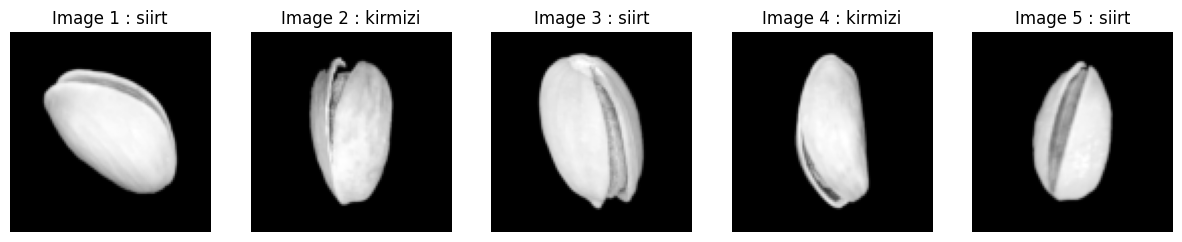

In [8]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(prepImg[(i*12)], cmap='gray')
    plt.title(f'Image {i+1} : {allImg[i*12].split()[0]}')
    plt.axis('off')
plt.show()

#### Pixel Value Distribution for an Image

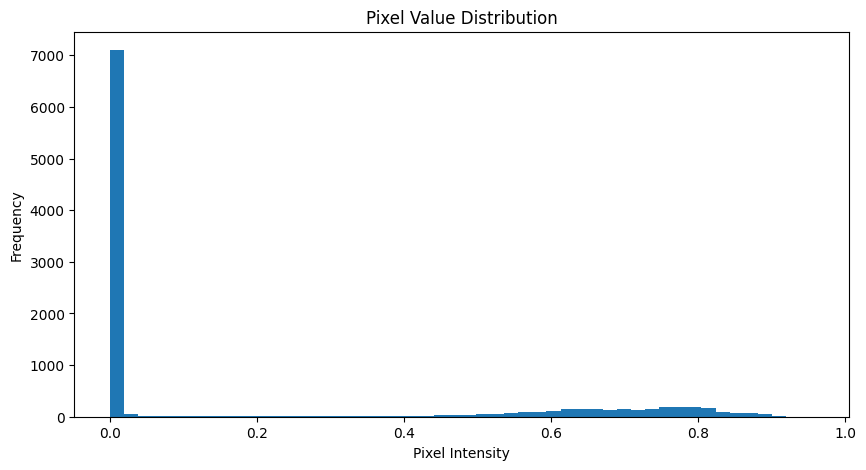

In [9]:
plt.figure(figsize=(10,5))
plt.hist(prepImg[134].flatten(), bins=50)
plt.title('Pixel Value Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

## B. Split Data

Saat data di import, telah diubah menjadi 100, 100. Sehingga tidak akan dilakukan lagi

#### Create Noise Images

In [10]:
def addNoise(img, mean=0.0, std=0.1):
    noise = np.random.normal(mean, std, size=img.shape)
    noisyImg = img+noise

    return np.clip(noisyImg, 0., 1.)

noisyImg = addNoise(prepImg)

print(prepImg.shape, noisyImg.shape)

(1074, 100, 100) (1074, 100, 100)


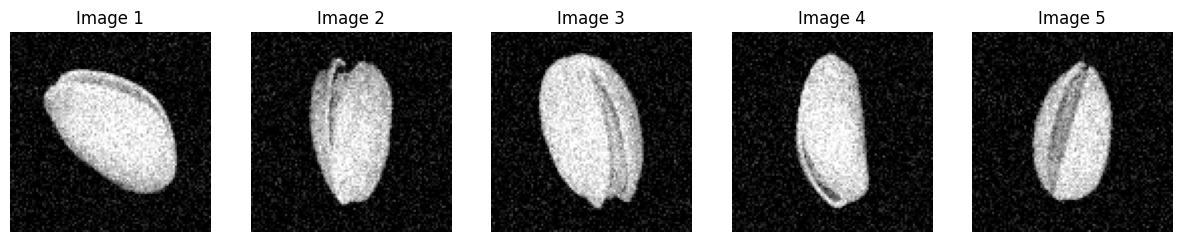

In [11]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(noisyImg[(i*12)], cmap='gray')
    plt.title(f'Image {i+1}')
    plt.axis('off')
plt.show()

#### Splitting Data and Expand Dimension for grayscale

In [12]:
xTrainNoisy, xTempNoisy = train_test_split(noisyImg, test_size=0.2, random_state=42)
xValNoisy, xTestNoisy = train_test_split(xTempNoisy, test_size=0.5, random_state=42)

xTrain, xTemp = train_test_split(prepImg, test_size=0.2, random_state=42)
xVal, xTest = train_test_split(xTemp, test_size=0.5, random_state=42)

print(xTrainNoisy.shape, xValNoisy.shape, xTestNoisy.shape)
print(xTrain.shape, xVal.shape, xTest.shape)

(859, 100, 100) (107, 100, 100) (108, 100, 100)
(859, 100, 100) (107, 100, 100) (108, 100, 100)


In [13]:
xTrainNoisy = np.expand_dims(xTrainNoisy, axis=-1)
xValNoisy = np.expand_dims(xValNoisy, axis=-1)
xTestNoisy = np.expand_dims(xTestNoisy, axis=-1)

xTrain = np.expand_dims(xTrain, axis=-1)
xVal = np.expand_dims(xVal, axis=-1)
xTest = np.expand_dims(xTest, axis=-1)

print(xTrainNoisy.shape, xValNoisy.shape, xTestNoisy.shape)
print(xTrain.shape, xVal.shape, xTest.shape)

(859, 100, 100, 1) (107, 100, 100, 1) (108, 100, 100, 1)
(859, 100, 100, 1) (107, 100, 100, 1) (108, 100, 100, 1)


## Creating Model

In [14]:
inputImg = Input(shape=(100, 100, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputImg)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoder = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoder)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoder = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(inputImg, decoder)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
autoencoderHistory = autoencoder.fit(xTrainNoisy, xTrain,
                                     epochs=20,
                                     batch_size=32,
                                     validation_data = (xValNoisy, xVal),
                                     verbose=2)

Epoch 1/20
27/27 - 10s - 360ms/step - loss: 0.0618 - val_loss: 0.0049
Epoch 2/20
27/27 - 3s - 101ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 3/20
27/27 - 0s - 17ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 4/20
27/27 - 1s - 23ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 5/20
27/27 - 1s - 19ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 6/20
27/27 - 1s - 23ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 7/20
27/27 - 1s - 19ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 8/20
27/27 - 1s - 20ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 9/20
27/27 - 1s - 21ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 10/20
27/27 - 0s - 18ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/20
27/27 - 0s - 17ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/20
27/27 - 1s - 23ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 13/20
27/27 - 0s - 17ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 14/20
27/27 - 0s - 17ms/step - loss: 9.8412e-04 - val_loss: 0.0011
Epoch 15/20
27/27 - 0s - 17ms/step -

In [16]:
autoencoderLoss = autoencoder.evaluate(xTestNoisy, xTest)
print(f'Autoencoder MSE: {autoencoderLoss:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 7.1954e-04
Autoencoder MSE: 0.0007


In [17]:
encPred = autoencoder.predict(xTestNoisy)
encPred.shape

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


(108, 100, 100, 1)

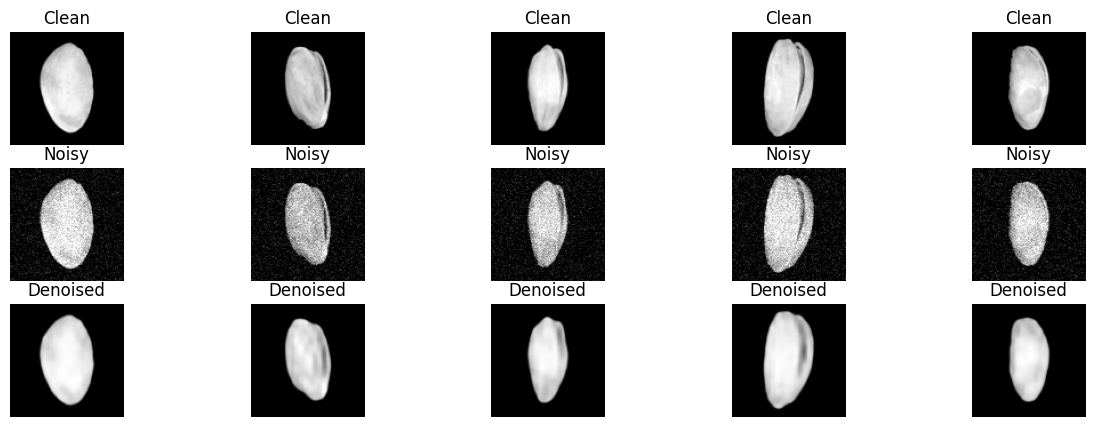

In [18]:
plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(xTest[i], cmap='gray')
    plt.title('Clean')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(xTestNoisy[i], cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(encPred[i], cmap='gray')
    plt.title('Denoised')
    plt.axis('off')
plt.show()

In [19]:
xTestNoisy.shape

(108, 100, 100, 1)

In [43]:
encPredSsim = []

for i in range(encPred.shape[0]):
    pred = encPred[i].squeeze()
    clean = xTest[i].squeeze()

    score, diff = ssim(pred, clean, full=True, data_range=1.0)

    encPredSsim.append(score)

In [44]:
avgSsim = np.mean(encPredSsim)
print("SSIM Score:", avgSsim)

SSIM Score: 0.9532207432818397


## Membuat Model Modifikasi untuk Autoencoder

In [29]:
inputModImg = Input(shape=(100, 100, 1))
xMod = Conv2D(64, (3, 3), activation='relu', padding='same')(inputModImg)
xMod = MaxPooling2D((2, 2), padding='same')(xMod)
xMod = Conv2D(128, (3, 3), activation='relu', padding='same')(xMod)
xMod = MaxPooling2D((2, 2), padding='same')(xMod)
xMod = Conv2D(256, (3, 3), activation='relu', padding='same')(xMod)
encoderMod = MaxPooling2D((2, 2), padding='same')(xMod)

xMod = Conv2D(256, (3, 3), activation='relu', padding='same')(encoderMod)
xMod = Conv2DTranspose(256, (3, 3), strides=(2, 2), activation='relu', padding='same')(xMod)
xMod = Cropping2D(cropping=((0, 1), (0, 1)))(xMod)
xMod = Conv2D(128, (3, 3), activation='relu', padding='same')(xMod)
xMod = Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu', padding='same')(xMod)
xMod = Conv2D(64, (3, 3), activation='relu', padding='same')(xMod)
xMod = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(xMod)
decoderMod = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(xMod)

autoencoderMod = Model(inputModImg, decoderMod)
autoencoderMod.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoderMod.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 100, 100, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 26, 26, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_1 (Cropping2D)       │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 25, 25, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 50, 50, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 50, 50, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 100, 100, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 100, 100, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,103,745 (8.03 MB)

 Trainable params: 2,103,745 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
autoencoderModHistory = autoencoderMod.fit(xTrainNoisy, xTrain,
                                     epochs=100,
                                     batch_size=32,
                                     validation_data = (xValNoisy, xVal),
                                     verbose=2, callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, monitor='val_loss')
    ])

Epoch 1/100
27/27 - 11s - 408ms/step - loss: 0.0808 - val_loss: 0.0114
Epoch 2/100
27/27 - 4s - 136ms/step - loss: 0.0067 - val_loss: 0.0046
Epoch 3/100
27/27 - 2s - 70ms/step - loss: 0.0039 - val_loss: 0.0038
Epoch 4/100
27/27 - 2s - 70ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 5/100
27/27 - 2s - 73ms/step - loss: 0.0029 - val_loss: 0.0034
Epoch 6/100
27/27 - 2s - 92ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 7/100
27/27 - 3s - 97ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 8/100
27/27 - 2s - 71ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 9/100
27/27 - 3s - 94ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 10/100
27/27 - 3s - 97ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 11/100
27/27 - 3s - 94ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 12/100
27/27 - 3s - 93ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 13/100
27/27 - 2s - 73ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 14/100
27/27 - 2s - 72ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 15/100
27/27 - 2s - 

In [36]:
autoencoderModLoss = autoencoderMod.evaluate(xTestNoisy, xTest)
print(f'Autoencoder MSE: {autoencoderModLoss:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 4.3038e-04
Autoencoder MSE: 0.0004


In [37]:
encModPred = autoencoderMod.predict(xTestNoisy)
encModPred.shape

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


(108, 100, 100, 1)

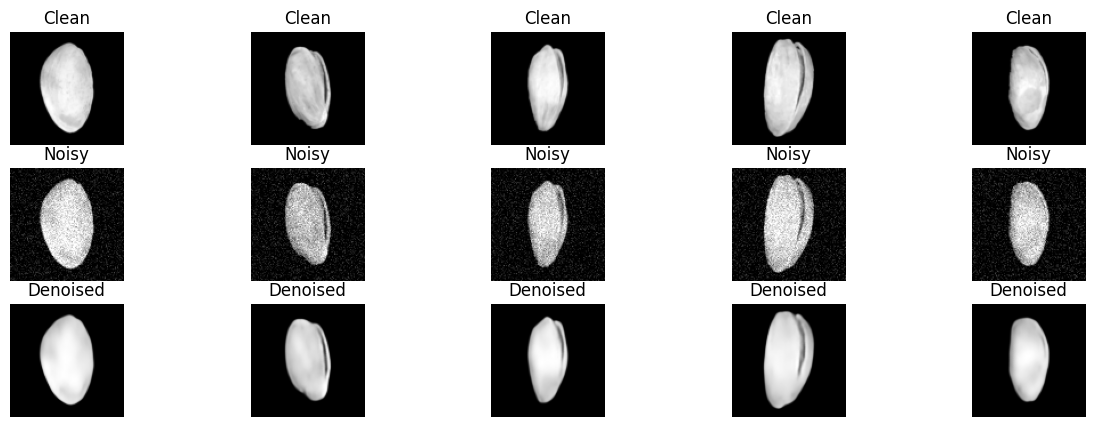

In [38]:
plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(xTest[i], cmap='gray')
    plt.title('Clean')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(xTestNoisy[i], cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(encModPred[i], cmap='gray')
    plt.title('Denoised')
    plt.axis('off')
plt.show()

In [41]:
encModPredSsim = []

for i in range(encModPred.shape[0]):
    pred = encModPred[i].squeeze()
    clean = xTest[i].squeeze()

    score, diff = ssim(pred, clean, full=True, data_range=1.0)

    encModPredSsim.append(score)

In [42]:
avgModSsim = np.mean(encModPredSsim)
print("SSIM Score:", avgModSsim)

SSIM Score: 0.9640555517917767
